In [1]:
import pandas as pd
import matplotlib.pyplot as plt

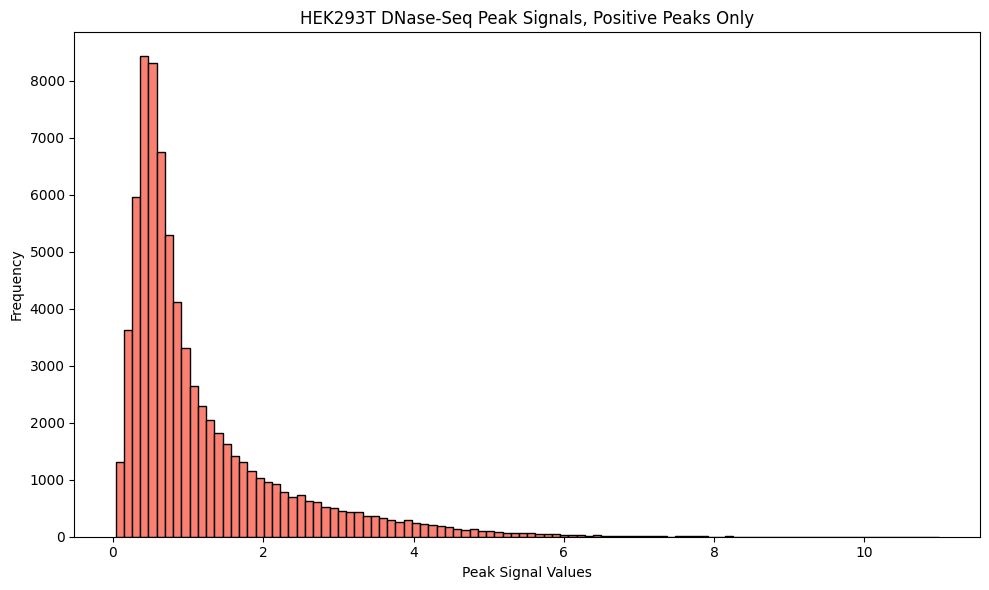

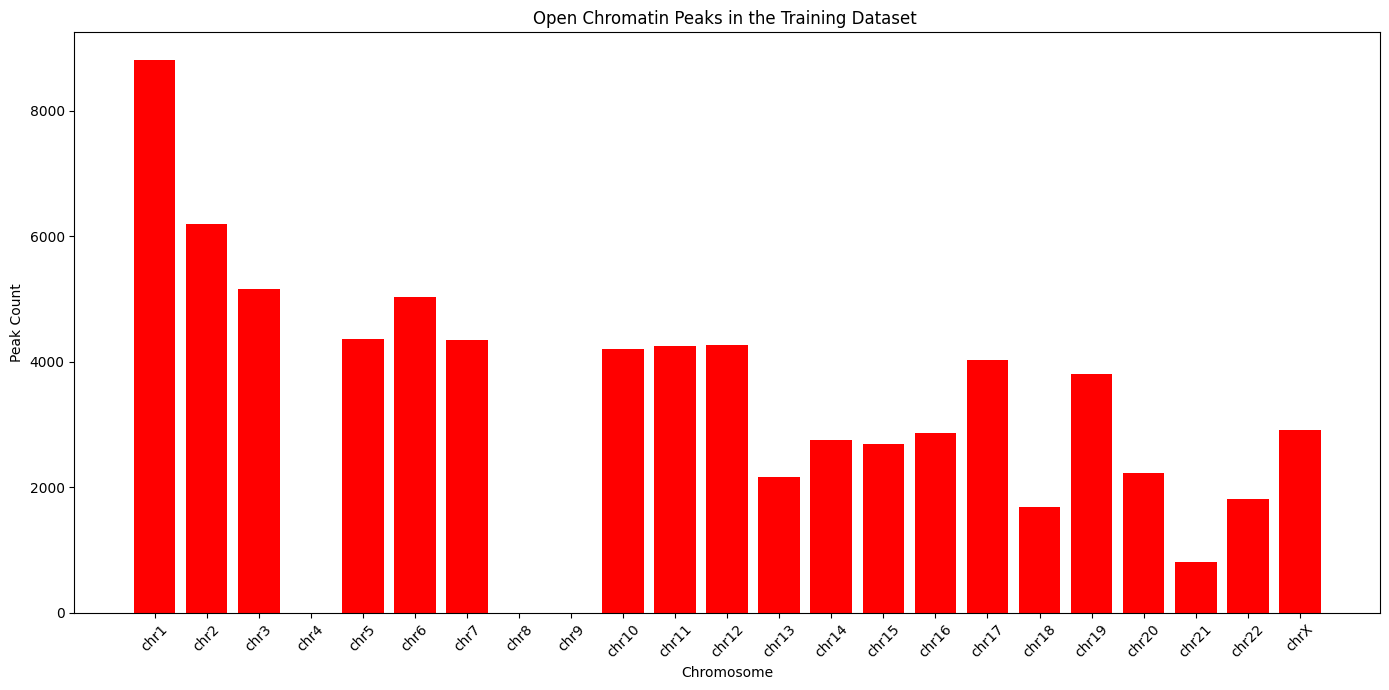

In [2]:
df = pd.read_csv('/media/zihengc/T7/THP1_machinelearning/expand_peaks_500bp_hg38/HEK293T_DNase_ENCODE.narrowPeak.train.bed',sep='\t',header= None )
# Set up the figure size and resolution
plt.figure(figsize=(10, 6), dpi=100)

# Plotting the histogram
plt.hist(df[6], bins=100, color='salmon', edgecolor='black')

# Adding labels and title
plt.xlabel('Peak Signal Values')
plt.ylabel('Frequency')
plt.title('HEK293T DNase-Seq Peak Signals, Positive Peaks Only')

# Adding a grid for better readability
#plt.grid(False, linestyle='--', linewidth=0.5)

# Show the plot
plt.tight_layout()
plt.show()
##############################################################################################################
# Counting peaks per chromosome
peak_counts = df[0].value_counts().sort_index()

# Suppose bed_df is your DataFrame loaded from the BED file
#peak_counts = bed_df['chr'].value_counts().sort_index()

# Ensuring chr4, chr8, and chr9 are included with zero counts if they are absent
for chrom in ['chr4', 'chr8', 'chr9']:
    if chrom not in peak_counts:
        peak_counts[chrom] = 0

# Now, sorting the chromosomes including these
def sort_chromosomes(chrom_list):
    def chromosome_key(chromosome):
        # Sort numerically, but put X and Y at the end
        return (1000 if chromosome == 'chrX' else
                1001 if chromosome == 'chrY' else
                int(chromosome[3:]))
    return sorted(chrom_list, key=chromosome_key)

sorted_chrs = sort_chromosomes(peak_counts.index.tolist())
sorted_peak_counts = peak_counts.loc[sorted_chrs]

colors = ['grey' if x in ['chr4', 'chr8', 'chr9'] else 'red' for x in sorted_peak_counts.index]

plt.figure(figsize=(14, 7))
plt.bar(sorted_peak_counts.index, sorted_peak_counts.values, color=colors)
plt.xlabel('Chromosome')
plt.ylabel('Peak Count')
plt.title('Open Chromatin Peaks in the Training Dataset ')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



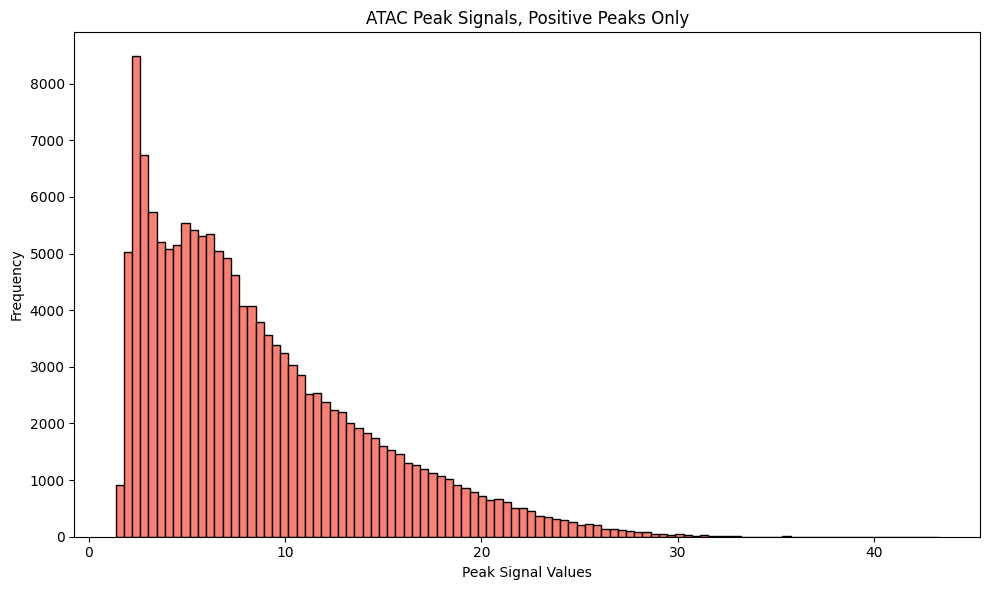

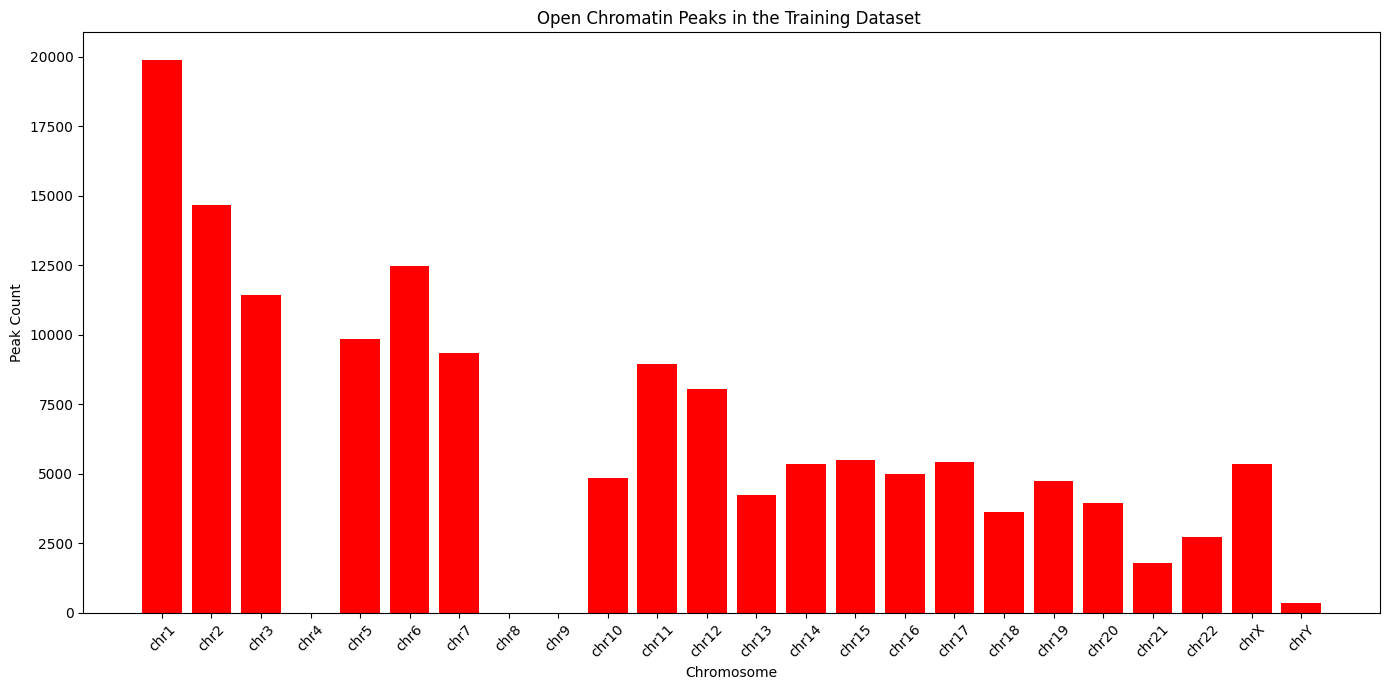

In [3]:
df = pd.read_csv('/media/zihengc/T7/THP1_machinelearning/expand_peaks_500bp_hg38/THP1_Naive_4hrs.idr.optimal_peak.narrowPeak.train.bed',sep='\t',header= None )
# Set up the figure size and resolution
plt.figure(figsize=(10, 6), dpi=100)

# Plotting the histogram
plt.hist(df[6], bins=100, color='salmon', edgecolor='black')

# Adding labels and title
plt.xlabel('Peak Signal Values')
plt.ylabel('Frequency')
plt.title('ATAC Peak Signals, Positive Peaks Only')

# Adding a grid for better readability
#plt.grid(False, linestyle='--', linewidth=0.5)

# Show the plot
plt.tight_layout()
plt.show()
##############################################################################################################
# Counting peaks per chromosome
peak_counts = df[0].value_counts().sort_index()

# Suppose bed_df is your DataFrame loaded from the BED file
#peak_counts = bed_df['chr'].value_counts().sort_index()

# Ensuring chr4, chr8, and chr9 are included with zero counts if they are absent
for chrom in ['chr4', 'chr8', 'chr9']:
    if chrom not in peak_counts:
        peak_counts[chrom] = 0

# Now, sorting the chromosomes including these
def sort_chromosomes(chrom_list):
    def chromosome_key(chromosome):
        # Sort numerically, but put X and Y at the end
        return (1000 if chromosome == 'chrX' else
                1001 if chromosome == 'chrY' else
                int(chromosome[3:]))
    return sorted(chrom_list, key=chromosome_key)

sorted_chrs = sort_chromosomes(peak_counts.index.tolist())
sorted_peak_counts = peak_counts.loc[sorted_chrs]

colors = ['grey' if x in ['chr4', 'chr8', 'chr9'] else 'red' for x in sorted_peak_counts.index]

plt.figure(figsize=(14, 7))
plt.bar(sorted_peak_counts.index, sorted_peak_counts.values, color=colors)
plt.xlabel('Chromosome')
plt.ylabel('Peak Count')
plt.title('Open Chromatin Peaks in the Training Dataset ')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



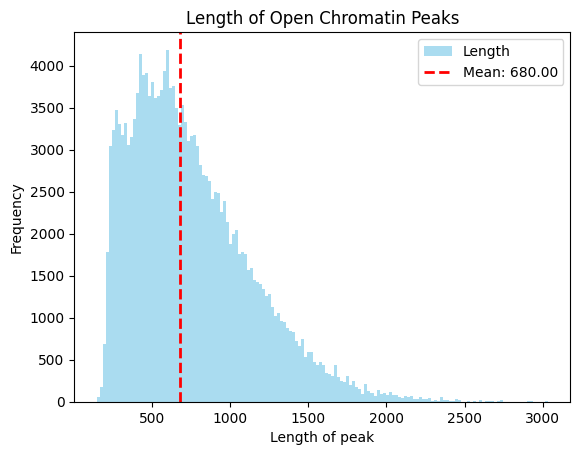

In [7]:
import numpy as np
df = pd.read_csv('/media/zihengc/T7/THP1_machinelearning/peak_files/Naive_4hrs/THP1_Naive_4hrs.idr.optimal_peak.narrowPeak.gz',sep='\t',header=None)
df['Length'] = df[2]-df[1]

data = df['Length']
# Calculate the mean
mean_value = np.median(data)

# Create the histogram
plt.hist(data, bins=150, color='skyblue', alpha=0.7, label='Length')

# Highlight the mean value
plt.axvline(mean_value, color='r', linestyle='dashed', linewidth=2, label=f'Mean: {mean_value:.2f}')

# Add labels and title
plt.xlabel('Length of peak')
plt.ylabel('Frequency')
plt.title('Length of Open Chromatin Peaks')
plt.legend()

# Show the plot
plt.show()


/tmp/ipykernel_18167/1458012381.py:1: DtypeWarning: Columns (3,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/media/zihengc/T7/THP1_machinelearning/expand_peaks_500bp_hg38/THP1_Naive_4hrs.idr.optimal_peak.narrowPeak.train.withNeg.bed',sep='\t',header= None )


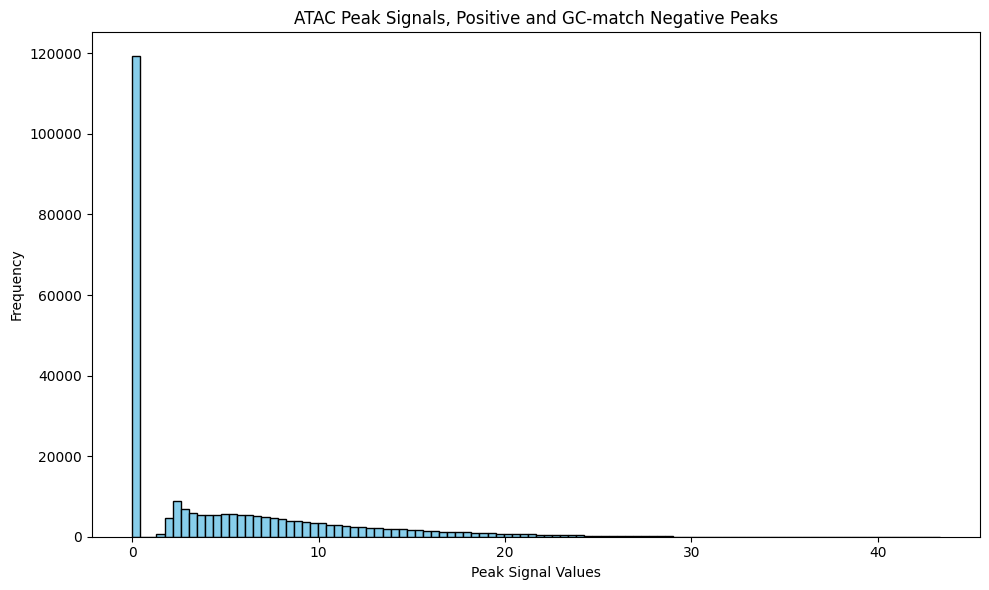

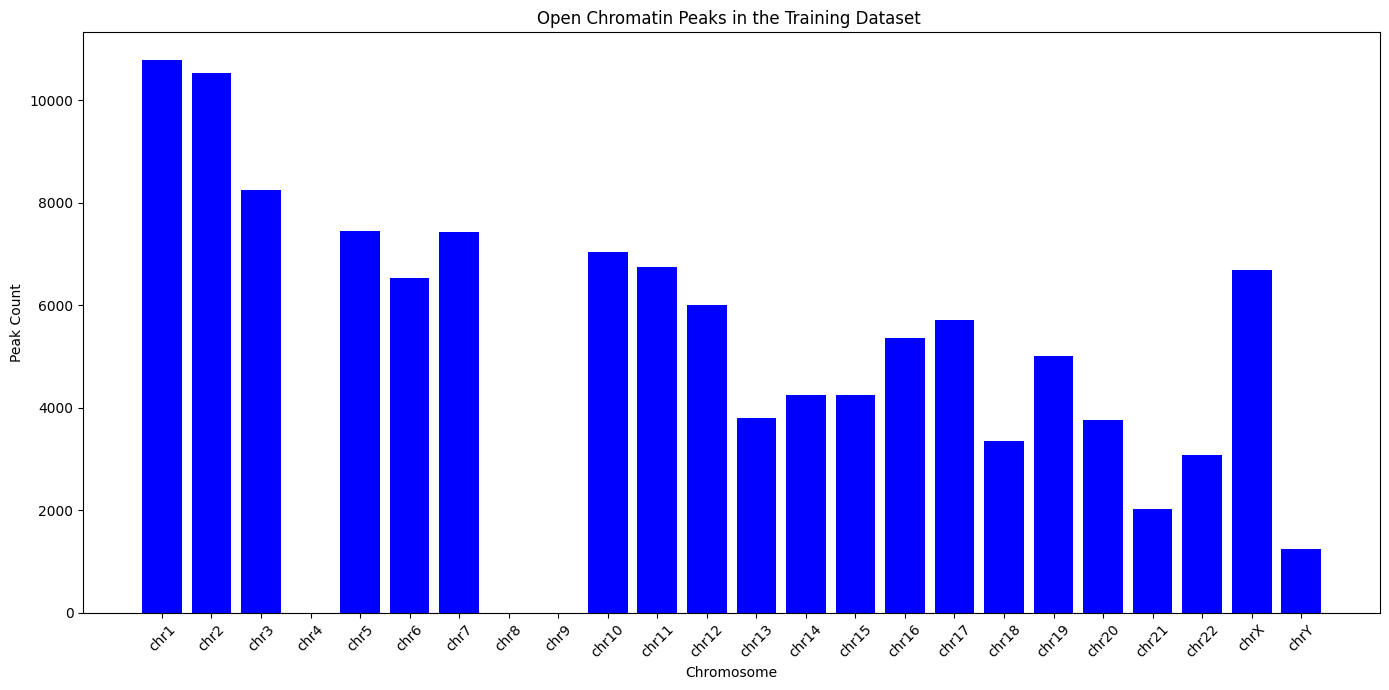

In [8]:
df = pd.read_csv('/media/zihengc/T7/THP1_machinelearning/expand_peaks_500bp_hg38/THP1_Naive_4hrs.idr.optimal_peak.narrowPeak.train.withNeg.bed',sep='\t',header= None )
# Set up the figure size and resolution
plt.figure(figsize=(10, 6), dpi=100)

# Plotting the histogram
import seaborn as sns
#sns.kdeplot(df[6])
plt.hist(df[6], bins=100, color='skyblue', edgecolor='black')

# Adding labels and title
plt.xlabel('Peak Signal Values')
plt.ylabel('Frequency')
plt.title('ATAC Peak Signals, Positive and GC-match Negative Peaks')

# Adding a grid for better readability
#plt.grid(False, linestyle='--', linewidth=0.5)

# Show the plot
plt.tight_layout()
plt.show()
#########################################################################3
# Counting peaks per chromosome
peak_counts = df[df[6]==0][0].value_counts().sort_index()


# Ensuring chr4, chr8, and chr9 are included with zero counts if they are absent
for chrom in ['chr4', 'chr8', 'chr9']:
    if chrom not in peak_counts:
        peak_counts[chrom] = 0

# Now, sorting the chromosomes including these
def sort_chromosomes(chrom_list):
    def chromosome_key(chromosome):
        # Sort numerically, but put X and Y at the end
        return (1000 if chromosome == 'chrX' else
                1001 if chromosome == 'chrY' else
                int(chromosome[3:]))
    return sorted(chrom_list, key=chromosome_key)

sorted_chrs = sort_chromosomes(peak_counts.index.tolist())
sorted_peak_counts = peak_counts.loc[sorted_chrs]

colors = ['grey' if x in ['chr4', 'chr8', 'chr9'] else 'blue' for x in sorted_peak_counts.index]

plt.figure(figsize=(14, 7))
plt.bar(sorted_peak_counts.index, sorted_peak_counts.values, color=colors)
plt.xlabel('Chromosome')
plt.ylabel('Peak Count')
plt.title('Open Chromatin Peaks in the Training Dataset ')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


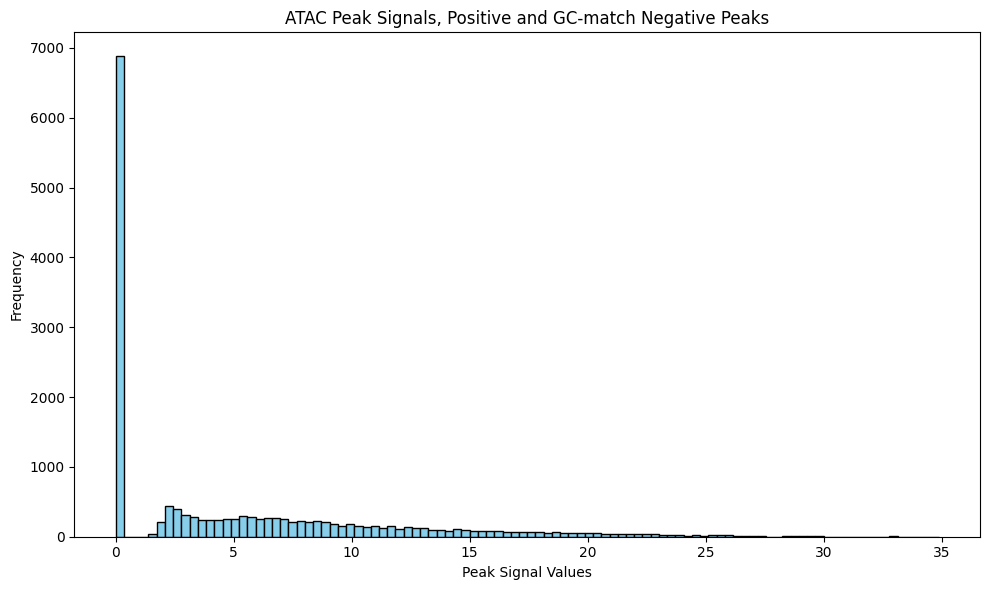

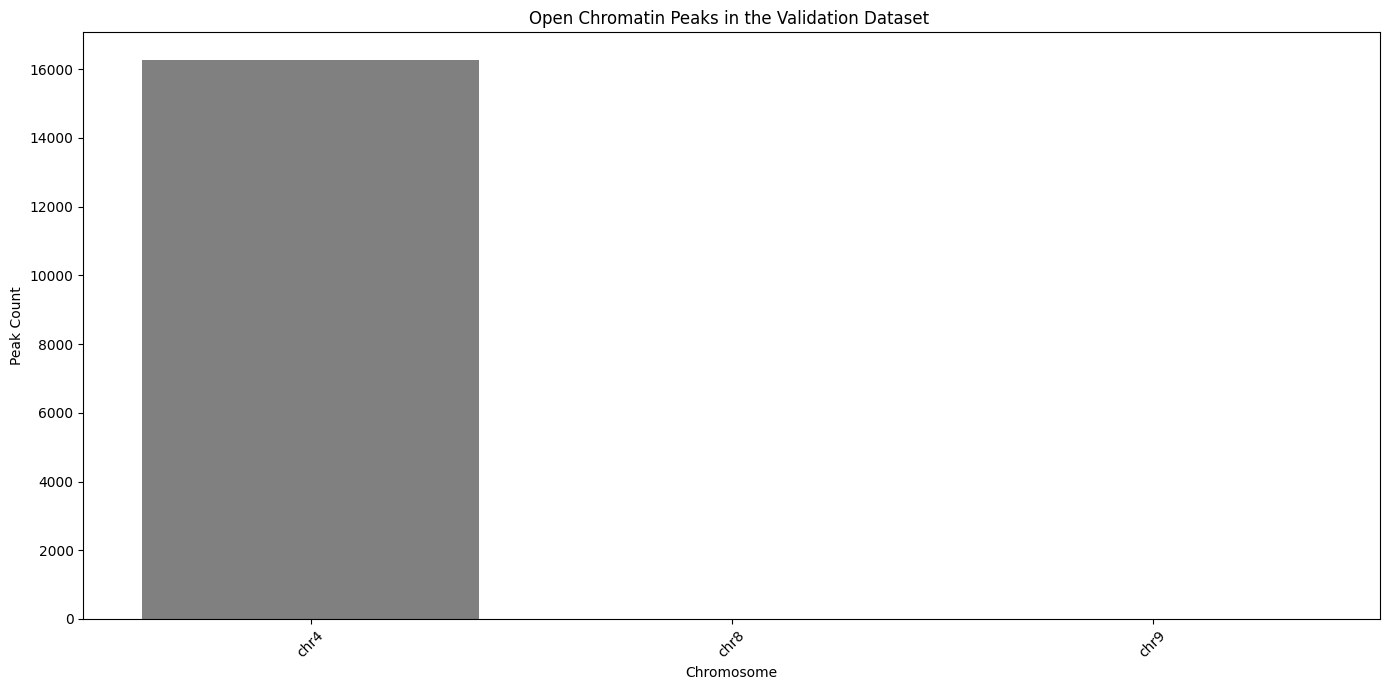

In [10]:
df = pd.read_csv('/media/zihengc/T7/THP1_machinelearning/expand_peaks_500bp_hg38/THP1_Naive_4hrs.idr.optimal_peak.narrowPeak.validation.withNeg.bed',sep='\t',header= None )
# Set up the figure size and resolution
plt.figure(figsize=(10, 6), dpi=100)

# Plotting the histogram
import seaborn as sns
#sns.kdeplot(df[6])
plt.hist(df[6], bins=100, color='skyblue', edgecolor='black')

# Adding labels and title
plt.xlabel('Peak Signal Values')
plt.ylabel('Frequency')
plt.title('ATAC Peak Signals, Positive and GC-match Negative Peaks')

# Adding a grid for better readability
#plt.grid(False, linestyle='--', linewidth=0.5)

# Show the plot
plt.tight_layout()
plt.show()
#########################################################################
# Counting peaks per chromosome
peak_counts = df[0].value_counts().sort_index()

# Ensuring chr4, chr8, and chr9 are included with zero counts if they are absent
for chrom in ['chr4', 'chr8', 'chr9']:
    if chrom not in peak_counts:
        peak_counts[chrom] = 0

# Now, sorting the chromosomes including these
def sort_chromosomes(chrom_list):
    def chromosome_key(chromosome):
        # Sort numerically, but put X and Y at the end
        return (1000 if chromosome == 'chrX' else
                1001 if chromosome == 'chrY' else
                int(chromosome[3:]))
    return sorted(chrom_list, key=chromosome_key)

sorted_chrs = sort_chromosomes(peak_counts.index.tolist())
sorted_peak_counts = peak_counts.loc[sorted_chrs]

colors = ['grey' if x in ['chr4', 'chr8', 'chr9'] else 'blue' for x in sorted_peak_counts.index]

plt.figure(figsize=(14, 7))
plt.bar(sorted_peak_counts.index, sorted_peak_counts.values, color=colors)
plt.xlabel('Chromosome')
plt.ylabel('Peak Count')
plt.title('Open Chromatin Peaks in the Validation Dataset ')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
